## Loading Main Packages

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

import wave_aux as wa

un_var= {"Hs": " [m]","Tp": " [s]","Dirp": " [°]","Dirm": " [°]"}
T_fit=np.linspace(2.0, 250, 1000)
P_fit = 1 - 1/T_fit

### Loading Data File

In [2]:
fin='./Point_out_000260.dat'
pdW=wa.readWave(1,'../data/'+fin,0)
pdW

,Hs,T02,T01,Tm10,Tp,Dirm,Dirp,Spr,Hs0,Tp0,...,Dirp2,gam2,spr2,Hs3,Tp3,Dirp3,gam3,spr3,uw,vw
YYYY-MM-DD hh:mm:ss,,,,,,,,,,,,,,,,,,,,,
1979-01-01 00:00:00,0.000,1.52,1.52,1.52,1.96,270.0,227.3,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.51,5.12
1979-01-01 01:00:00,0.232,1.47,1.58,1.74,1.96,228.2,227.3,26.1,0.232,1.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.30,6.07
1979-01-01 02:00:00,0.706,2.23,2.41,2.65,3.02,229.1,226.5,31.7,0.706,3.02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.40,8.38
1979-01-01 03:00:00,1.151,3.03,3.30,3.63,4.18,222.7,217.8,30.1,1.151,4.18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.65,8.66
1979-01-01 04:00:00,1.472,3.66,4.00,4.42,5.08,219.4,216.1,27.6,1.472,5.08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.12,7.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-30 20:00:00,1.140,4.57,5.20,6.09,7.52,205.5,221.8,37.8,NaN,NaN,...,152.6,2.24,0.5,0.257,4.43,280.2,2.20,0.4,-2.42,-2.08
2025-01-30 21:00:00,1.145,4.54,5.17,6.08,7.52,207.2,221.6,38.0,NaN,NaN,...,153.4,2.19,0.5,0.305,4.40,280.6,2.12,0.4,-2.58,-2.36
2025-01-30 22:00:00,1.154,4.46,5.10,6.02,7.51,209.0,221.2,39.2,NaN,NaN,...,159.3,2.27,0.4,0.356,4.37,281.0,2.06,0.5,-1.61,-0.75


## **Annual Maxima**

In [3]:
var='Hs'
# Calling function for Annual Maxima
df=wa.am(pdW,var)

# Sorting in descending order depending on Hs values
dfs = df.sort_values(by='Hs', ascending=True)

# Developing Plottin Position
n=len(dfs)
dfs['pp']=wa.plot_pos(df,var,method="weibull")
print(n)

47


In [4]:
# Fitting GEV to data
c, loc, scale = stats.genextreme.fit(dfs[var])
print(f"GEV parameters: c={c:.3f}, loc={loc:.3f}, scale={scale:.3f}")

GEV parameters: c=0.109, loc=3.969, scale=0.504


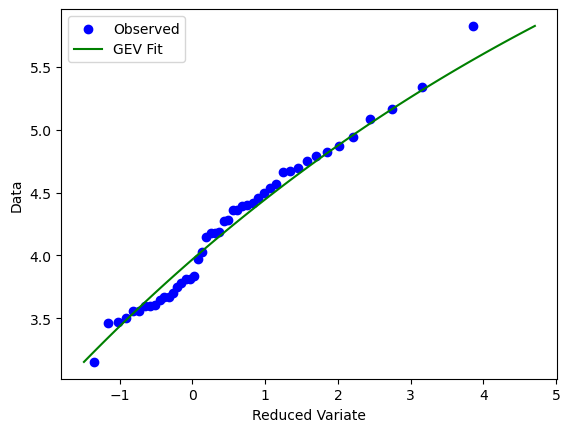

In [5]:
# CDF for plotting
#x_fit = np.linspace(2,10, 100)
x_fit = np.linspace(dfs[var].min(),dfs[var].max(), 100)
y_fit = stats.genextreme.cdf(x_fit, c, loc=loc, scale=scale)
y_fit_reduced = -np.log(-np.log(y_fit))
y = -np.log(-np.log(dfs['pp']))

plt.scatter(y, dfs['Hs'], color='blue', label='Observed')
plt.plot(y_fit_reduced, x_fit, color='green', label='GEV Fit')
plt.xlabel('Reduced Variate')
plt.ylabel('Data')
plt.legend()
plt.show()

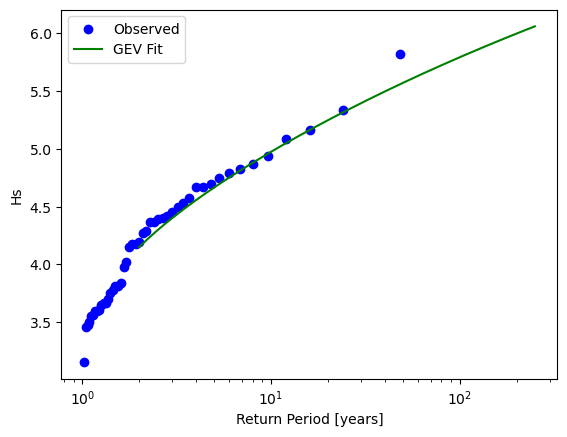

In [6]:
# Return periods for plotting (log scale often used)
T=1/(1-dfs['pp'])

# Convert T to non-exceedance probability

data_fit = stats.genextreme.ppf(P_fit, c, loc=loc, scale=scale)

plt.scatter(T, dfs[var], color='blue', label='Observed')
plt.plot(T_fit, data_fit, color='green', label='GEV Fit')
plt.xscale('log')  # commonly log scale for return period
plt.xlabel('Return Period [years]')
plt.ylabel(var)
plt.legend()
plt.show()

In [7]:
# Estimate confidence intervals using different methods (e.g., 'bootstrap', 'delta' method, 'profile' likelihood)
rL, ci_L_GEV, ci_U_GEV, param=wa.return_ci(dfs[var], T_fit, method="bootstrap", alpha=0.05, n_boot=1000)

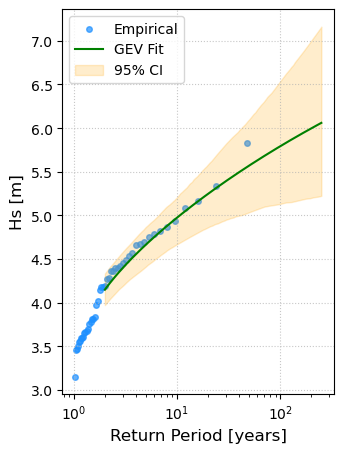


Return Period Quantiles (AM Method):
Return Period (years) | Quantile Value
----------------------------------------
                 2.0 |          4.150 m
                 5.0 |          4.666 m
                10.0 |          4.974 m
                25.0 |          5.330 m
                50.0 |          5.571 m
               100.0 |          5.793 m
               250.0 |          6.060 m


In [8]:
plt.figure(figsize=(3.5, 5))
plt.scatter(T, dfs[var], color='dodgerblue', label='Empirical', s=16, alpha=0.7)
plt.plot(T_fit, rL, color='green', label='GEV Fit')
plt.fill_between(T_fit, ci_L_GEV, ci_U_GEV,
                 color='orange', alpha=0.2,
                 label='95% CI')
plt.xscale('log')
plt.xlabel('Return Period [years]', fontsize=12)
plt.ylabel(var+un_var[var], fontsize=12)
plt.legend()
plt.grid(True, alpha=0.7, linestyle='dotted')
plt.show()

# Print return period values
print("\nReturn Period Quantiles (AM Method):")
print("Return Period (years) | Quantile Value")
print("-" * 40)
return_periods = np.array([2, 5, 10, 25, 50, 100, 250])
P_ret = 1 - 1/return_periods
quantiles_am = stats.genextreme.ppf(P_ret, param[0], loc=param[1], scale=param[2])
for T_val, q_val in zip(return_periods, quantiles_am):
    print(f"{T_val:20.1f} | {q_val:14.3f} m")

In [9]:
# Calculate return period for a given Hs value
c=param[0]
loc=param[1]
scale=param[2]
hs_value = 6.0  # Change this to your desired value
T_calculated = wa.value_to_return_period(hs_value, c, loc, scale)
print(f"For {var} = {hs_value:.2f} m, the return period is {T_calculated:.2f} years")

For Hs = 6.00 m, the return period is 201.66 years


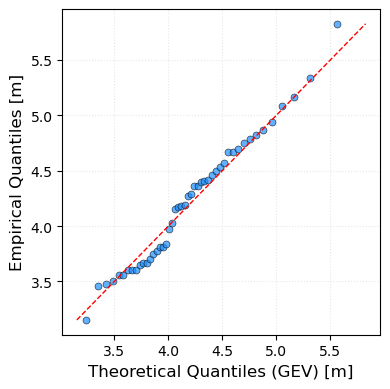

In [10]:
# Q-Q Plot: Theoretical vs Empirical Quantiles
# Sort observed data
observed_sorted = np.sort(dfs[var])
n = len(observed_sorted)

# Calculate empirical probabilities using plotting positions
# Using Weibull plotting position: (i)/(n+1)
empirical_prob = np.arange(1, n+1) / (n + 1)

# Calculate theoretical quantiles from fitted GEV distribution
theoretical_quantiles = stats.genextreme.ppf(empirical_prob, c, loc=loc, scale=scale)

# Create Q-Q plot
plt.figure(figsize=(4, 4))
plt.scatter(theoretical_quantiles, observed_sorted, color='dodgerblue', s=25, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
min_val = min(theoretical_quantiles.min(), observed_sorted.min())
max_val = max(theoretical_quantiles.max(), observed_sorted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.xlabel('Theoretical Quantiles (GEV)'+un_var[var], fontsize=12)
plt.ylabel('Empirical Quantiles'+un_var[var], fontsize=12)
#plt.title('Q-Q Plot: GEV Fit', fontsize=13, fontweight='bold')
#plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

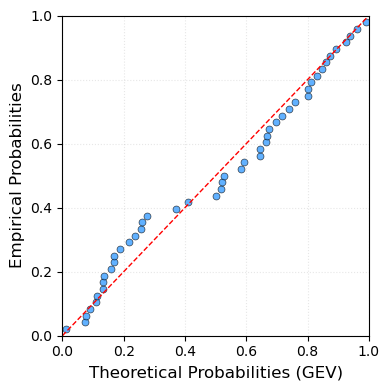

In [11]:
# P-P Plot: Theoretical vs Empirical Probabilities
# Sort observed data
observed_sorted = np.sort(dfs[var])
n = len(observed_sorted)

# Calculate empirical probabilities using plotting positions
# Using Weibull plotting position: (i)/(n+1)
empirical_prob = np.arange(1, n+1) / (n + 1)

# Calculate theoretical probabilities from fitted GEV distribution
theoretical_prob = stats.genextreme.cdf(observed_sorted, c, loc=loc, scale=scale)

# Create P-P plot
figsize = (4, 4)  # Adjust figure size as needed
plt.figure(figsize=figsize)
plt.scatter(theoretical_prob, empirical_prob, color='dodgerblue', s=25, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)

plt.xlabel('Theoretical Probabilities (GEV)', fontsize=12)
plt.ylabel('Empirical Probabilities', fontsize=12)
#plt.title('P-P Plot: GEV Fit', fontsize=13, fontweight='bold')
#plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

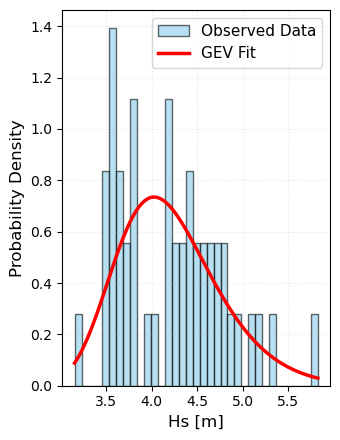

In [12]:
# PDF Plot: Histogram vs Fitted GEV Distribution
# Create x-values for the fitted PDF curve
x_pdf = np.linspace(dfs[var].min(), dfs[var].max(), 200)
# Calculate fitted PDF
pdf_fit = stats.genextreme.pdf(x_pdf, c, loc=loc, scale=scale)

# Create plot
figsize = (3.5, 4.5)  # Adjust figure size as needed
plt.figure(figsize=figsize)

# Plot histogram of observed data (normalized to represent density)
plt.hist(dfs[var], bins=35, density=True, alpha=0.6, color='skyblue', 
         edgecolor='black', label='Observed Data')

# Plot fitted GEV PDF
plt.plot(x_pdf, pdf_fit, 'r-', linewidth=2.5, label='GEV Fit')

plt.xlabel(var + un_var[var], fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
#plt.title('Probability Density Function: GEV Fit', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

# Peak Over Threshold

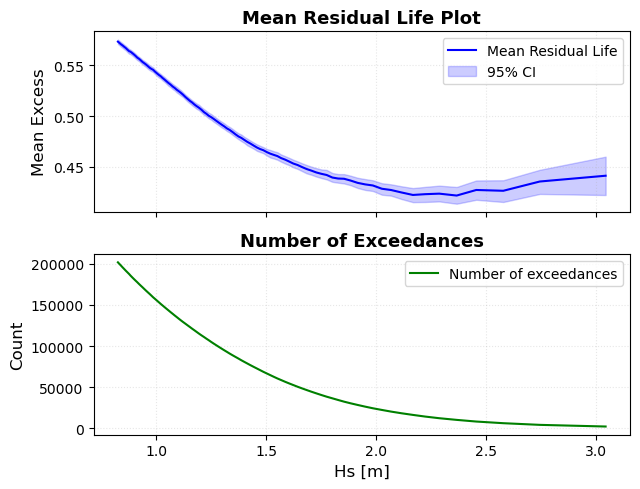

In [13]:
# Mean Residual Life (MRL) Plot for threshold selection
# The MRL plot helps identify appropriate thresholds for GPD fitting
# If GPD is appropriate above threshold u, MRL should be approximately linear

from joblib import Parallel, delayed

# Get the data and remove NaN values
data_mrl = pdW[var].dropna().values

# Sort data
data_sorted = np.sort(data_mrl)

# Define range of thresholds to evaluate
# Use quantiles from 0.5 to 0.995 to get a good range
quantiles = np.linspace(0.5, 0.995, 100)
thresholds = np.quantile(data_sorted, quantiles)

# Parallelized calculation of mean residual life with confidence intervals
def bootstrap_sample_mean(seed, excesses):
    """Single bootstrap iteration for MRL"""
    np.random.seed(seed)
    boot_sample = np.random.choice(excesses, size=len(excesses), replace=True)
    return np.mean(boot_sample)

def compute_mrl_with_ci(u, data_sorted, n_boot=500, alpha=0.05):
    """Compute MRL, exceedance count, and confidence intervals for a single threshold"""
    excesses = data_sorted[data_sorted > u] - u
    if len(excesses) == 0:
        return (np.nan, 0, np.nan, np.nan)
    
    # Calculate MRL
    mrl = np.mean(excesses)
    n_exc = len(excesses)
    
    # Bootstrap confidence intervals
    if len(excesses) < 10:  # Skip CI if too few exceedances
        return (mrl, n_exc, np.nan, np.nan)
    
    # Parallelized bootstrap resampling
    boot_mrl = Parallel(n_jobs=-1, backend='loky')(
        delayed(bootstrap_sample_mean)(i, excesses) for i in range(n_boot)
    )
    
    # Calculate confidence intervals
    ci_lower = np.percentile(boot_mrl, 100 * alpha / 2)
    ci_upper = np.percentile(boot_mrl, 100 * (1 - alpha / 2))
    
    return (mrl, n_exc, ci_lower, ci_upper)

# Parallel execution across thresholds
results = Parallel(n_jobs=-1, backend='loky')(
    delayed(compute_mrl_with_ci)(u, data_sorted) for u in thresholds
)

# Unpack results
mrl_values = np.array([r[0] for r in results])
n_exceedances = np.array([r[1] for r in results])
mrl_ci_lower = np.array([r[2] for r in results])
mrl_ci_upper = np.array([r[3] for r in results])

# Create MRL plot with confidence intervals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 5), sharex=True)

# Top panel: MRL plot with confidence intervals
ax1.plot(thresholds, mrl_values, 'b-', linewidth=1.5, label='Mean Residual Life')
ax1.fill_between(thresholds, mrl_ci_lower, mrl_ci_upper, 
                 color='blue', alpha=0.2, label='95% CI')
#ax1.axvline(x=thrsld, color='red', linestyle='--', linewidth=1.5, label=f'Selected threshold = {thrsld:.2f} m')
ax1.set_ylabel('Mean Excess', fontsize=12)
ax1.set_title('Mean Residual Life Plot', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='dotted')
ax1.legend(fontsize=10)

# Bottom panel: Number of exceedances
ax2.plot(thresholds, n_exceedances, 'g-', linewidth=1.5, label='Number of exceedances')
#ax2.axvline(x=thrsld, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel(var + un_var[var], fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Number of Exceedances', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='dotted')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

#print(f"Current threshold: {thrsld:.3f} m")
#print(f"Mean excess at current threshold: {mrl_values[np.argmin(np.abs(thresholds - thrsld))]:.3f} m")
#print(f"Number of exceedances: {n_exceedances[np.argmin(np.abs(thresholds - thrsld))]}")
#print("\nNote: Look for regions where MRL is approximately linear - this suggests GPD is appropriate")

In [14]:
# Find peaks with minimum height and minimum distance
hrs_leg=24
thrsld=pdW[var].quantile(0.99)
peaks, properties = find_peaks(
    pdW[var].dropna(),
    height=thrsld,                        # Threshold
    distance=hrs_leg,                     # Time lag between peaks
    prominence=0.3                        # Peak must be prominent
)

# Extract peaks with full row data
peak_indices = pdW[var].dropna().index[peaks]
peaks_df = pdW.loc[peak_indices]

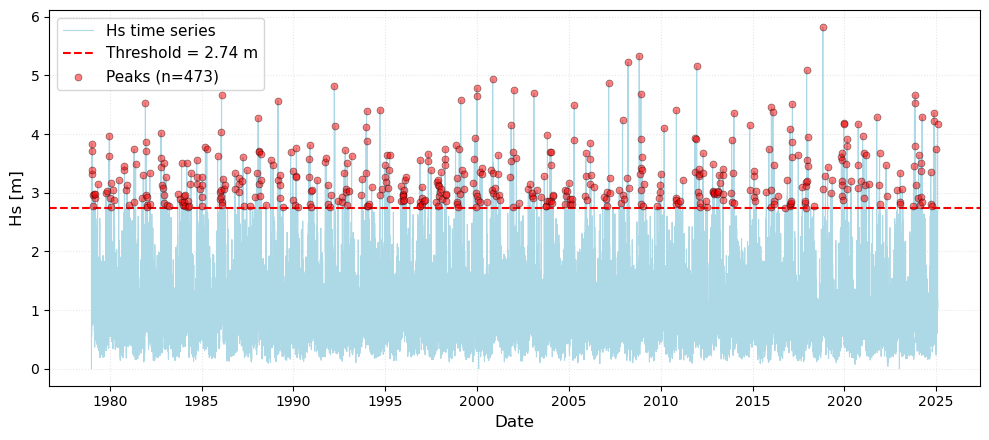

Total peaks identified: 473
Threshold value: 2.74 m
Mean peak value: 3.28 m
Max peak value: 5.83 m


In [15]:
# Plot original Hs time series with threshold and peaks
plt.figure(figsize=(10, 4.5))

# Plot the original Hs time series
plt.plot(pdW.index, pdW[var], color='lightblue', linewidth=0.8, label='Hs time series')

# Plot the threshold line
plt.axhline(y=thrsld, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {thrsld:.2f} m')

# Plot the identified peaks
plt.scatter(peaks_df.index, peaks_df[var], color='red', s=25, zorder=5, 
            edgecolors='black', alpha=0.5,linewidth=0.5, label=f'Peaks (n={len(peaks_df)})')

plt.xlabel('Date', fontsize=12)
plt.ylabel(var + un_var[var], fontsize=12)
#plt.title('Peak Over Threshold Analysis', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

print(f"Total peaks identified: {len(peaks_df)}")
print(f"Threshold value: {thrsld:.2f} m")
print(f"Mean peak value: {peaks_df[var].mean():.2f} m")
print(f"Max peak value: {peaks_df[var].max():.2f} m")

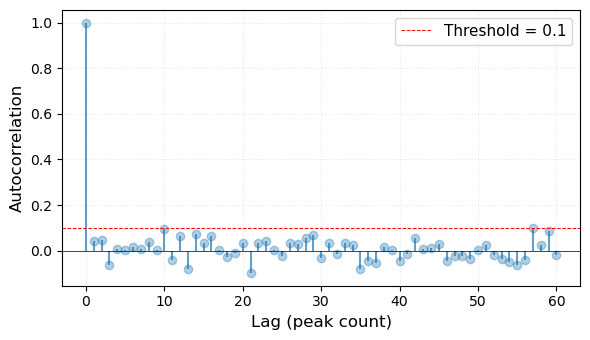

Decorrelation lag for peaks (at ACF < 0.1): 1 peaks
ACF at lag 0: 1.000
ACF at lag 1: 0.042
ACF at lag 2: 0.046
ACF at lag 5: 0.002
ACF at lag 10: 0.094
Total peaks analyzed: 473


In [16]:
# Evaluating autocorrelation and decorrelation time for peaks_df
# Get peaks values
peaks_hs = peaks_df[var].values

# Calculating ACF for peaks
acf_peaks = wa.calculate_acf(peaks_hs, nlags=min(60, len(peaks_hs)-1))

# Plot autocorrelation
plt.figure(figsize=(6, 3.5))
markerline, stemlines, baseline = plt.stem(range(len(acf_peaks)), acf_peaks, basefmt=' ')
stemlines.set_alpha(0.7)
markerline.set_alpha(0.35)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.axhline(y=0.1, color='red', linestyle='--', linewidth=0.7, label='Threshold = 0.1')
plt.xlabel('Lag (peak count)', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
#plt.title('Autocorrelation Function of Peaks', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()

# Find decorrelation lag for peaks
threshold = 0.1
decorr_lag_peaks = None
for i, acf_val in enumerate(acf_peaks):
    if acf_val < threshold:
        decorr_lag_peaks = i
        break

print(f"Decorrelation lag for peaks (at ACF < {threshold}): {decorr_lag_peaks} peaks")
print(f"ACF at lag 0: {acf_peaks[0]:.3f}")
if len(acf_peaks) > 1:
    print(f"ACF at lag 1: {acf_peaks[1]:.3f}")
if len(acf_peaks) > 2:
    print(f"ACF at lag 2: {acf_peaks[2]:.3f}")
if len(acf_peaks) > 5:
    print(f"ACF at lag 5: {acf_peaks[5]:.3f}")
if len(acf_peaks) > 10:
    print(f"ACF at lag 10: {acf_peaks[10]:.3f}")
print(f"Total peaks analyzed: {len(peaks_hs)}")

In [17]:
# GPD fitting to peaks over threshold
u=0.0
#u=thrsld
aaa=wa.gpd_fit(peaks_hs, u, method="l-mom")
c_gp=aaa[0]
loc_gp=aaa[1]
scale_gp=aaa[2]
b0=aaa[3][0]
b1=aaa[3][1]
b2=aaa[3][2]
l1=aaa[3][3]
l2=aaa[3][4]
l3=aaa[3][5]
t2=aaa[3][6]
t3=aaa[3][7]

In [18]:
print("=" * 70)
print("GENERALIZED PARETO DISTRIBUTION (POT METHOD)")
print("L-moments Fit: Hosking & Wallis (1997)")
print("=" * 70)
print(f"Probability Weighted Moments (PWM):")
print(f"  b0 (alpha): {b0:.6f}")
print(f"  b1 (beta):  {b1:.6f}")
print(f"  b2 (gamma): {b2:.6f}")
print(f"\nL-moments:")
print(f"  L1: {l1:.6f}")
print(f"  L2: {l2:.6f}")
print(f"  L3: {l3:.6f}")
print(f"\nL-moment Ratios:")
print(f"  t2 (L-CV):        {t2:.6f}")
print(f"  t3 (L-skewness):  {t3:.6f}")
print(f"\nGeneralized Pareto Parameters:")
print(f"  Shape (ξ):     {aaa[0]:.6f}")
print(f"  Scale (σ):     {aaa[2]:.6f}")
print(f"  Location (μ):  {aaa[1]:.6f} (Threshold: {thrsld:.6f})")
print(f"\nData Summary:")
print(f"  Number of peaks:       {len(peaks_hs)}")
print(f"  Number of exceedances: {len(peaks_hs)}")
print(f"  Mean exceedance:       {np.mean(peaks_hs):.6f}")
print(f"  Std exceedance:        {np.std(peaks_hs):.6f}")
print("=" * 70)

GENERALIZED PARETO DISTRIBUTION (POT METHOD)
L-moments Fit: Hosking & Wallis (1997)
Probability Weighted Moments (PWM):
  b0 (alpha): 3.284121
  b1 (beta):  1.775332
  b2 (gamma): 1.242002

L-moments:
  L1: 3.284121
  L2: 0.266544
  L3: 0.084139

L-moment Ratios:
  t2 (L-CV):        0.081161
  t3 (L-skewness):  0.315665

Generalized Pareto Parameters:
  Shape (ξ):     -0.040289
  Scale (σ):     0.565737
  Location (μ):  2.740294 (Threshold: 2.744000)

Data Summary:
  Number of peaks:       473
  Number of exceedances: 473
  Mean exceedance:       3.284121
  Std exceedance:        0.516117


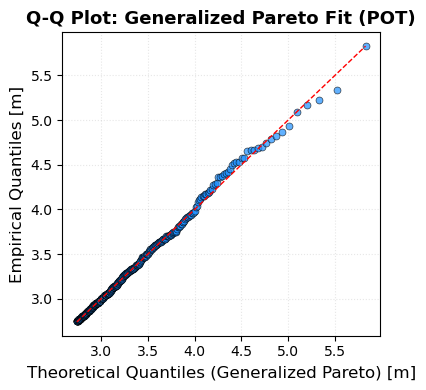

In [19]:
# Q-Q Plot: Theoretical vs Empirical Quantiles (Pareto)
# Sort observed peaks data
observed_sorted = np.sort(peaks_hs)
n_peaks = len(observed_sorted)

# Calculate empirical probabilities using plotting positions
empirical_prob_peaks = np.arange(1, n_peaks + 1) / (n_peaks + 1)

# Calculate theoretical quantiles from fitted Generalized Pareto distribution
theoretical_quantiles_gp = stats.genpareto.ppf(empirical_prob_peaks, c_gp, loc=loc_gp, scale=scale_gp)

# Create Q-Q plot
plt.figure(figsize=(4, 4))
plt.scatter(theoretical_quantiles_gp, observed_sorted, color='dodgerblue', 
            s=25, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
min_val = min(theoretical_quantiles_gp.min(), observed_sorted.min())
max_val = max(theoretical_quantiles_gp.max(), observed_sorted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.xlabel(f'Theoretical Quantiles (Generalized Pareto){un_var[var]}', fontsize=12)
plt.ylabel(f'Empirical Quantiles{un_var[var]}', fontsize=12)
plt.title('Q-Q Plot: Generalized Pareto Fit (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()


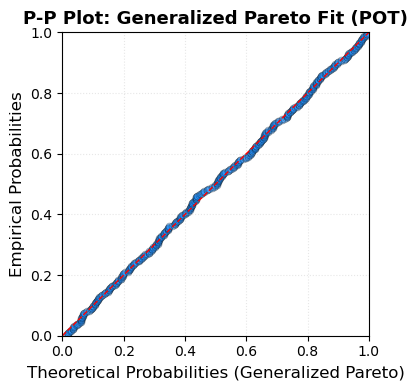

In [20]:
# P-P Plot: Theoretical vs Empirical Probabilities (Pareto)
# Calculate theoretical probabilities from fitted Generalized Pareto distribution
theoretical_prob_gp = stats.genpareto.cdf(observed_sorted, c_gp, loc=loc_gp, scale=scale_gp)

# Create P-P plot
plt.figure(figsize=(4, 4))
plt.scatter(theoretical_prob_gp, empirical_prob_peaks, color='dodgerblue', s=25, alpha=0.3, 
            edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)

plt.xlabel('Theoretical Probabilities (Generalized Pareto)', fontsize=12)
plt.ylabel('Empirical Probabilities', fontsize=12)
plt.title('P-P Plot: Generalized Pareto Fit (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()


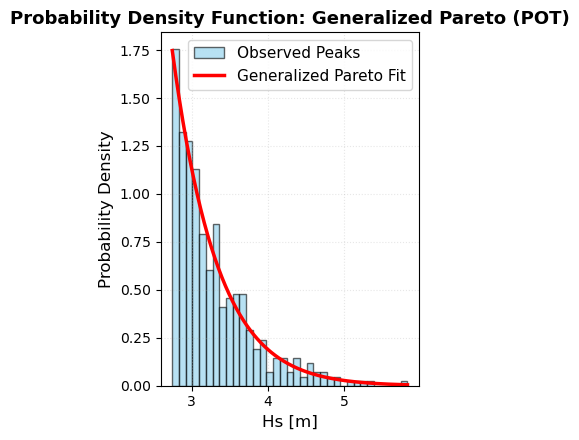

In [21]:
# PDF Plot: Histogram vs Fitted Generalized Pareto Distribution
# Create x-values for the fitted PDF curve
x_pdf_gp = np.linspace(peaks_hs.min(), peaks_hs.max(), 200)

# Calculate fitted PDF
pdf_fit_gp = stats.genpareto.pdf(x_pdf_gp, c_gp, loc=loc_gp, scale=scale_gp)

# Create plot
plt.figure(figsize=(3.5, 4.5))

# Plot histogram of observed data (normalized to represent density)
plt.hist(peaks_hs, bins=35, density=True, alpha=0.6, color='skyblue', 
         edgecolor='black', label='Observed Peaks')

# Plot fitted Generalized Pareto PDF
plt.plot(x_pdf_gp, pdf_fit_gp, 'r-', linewidth=2.5, label='Generalized Pareto Fit')

plt.xlabel(var + un_var[var], fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Probability Density Function: Generalized Pareto (POT)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()


Data duration: 46.08 years
Total peaks: 473
Average peaks per year: 10.26
-0.040288584282478605 2.740293783709302 0.5657367324827346


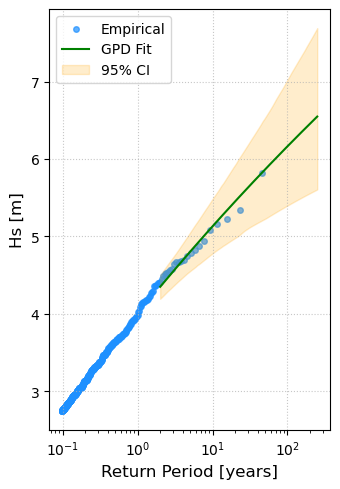


Return Period Quantiles (POT Method):
Return Period (years) | Quantile Value
----------------------------------------
                 2.0 |          4.350 m
                 5.0 |          4.800 m
                10.0 |          5.130 m
                25.0 |          5.553 m
                50.0 |          5.862 m
               100.0 |          6.163 m
               250.0 |          6.548 m


In [22]:
# Return Period Analysis for Generalized Pareto (POT method)
# Number of peaks per year
n_peaks_total = len(peaks_hs)
# Assuming the data covers a certain time period, calculate peaks per year
data_duration_years = (pdW.index[-1] - pdW.index[0]).days / 365.25
peaks_per_year = n_peaks_total / data_duration_years

print(f"Data duration: {data_duration_years:.2f} years")
print(f"Total peaks: {n_peaks_total}")
print(f"Average peaks per year: {peaks_per_year:.2f}")

# Compute return levels with confidence intervals using return_ci for GPD
rL_pot, ci_L_pot, ci_U_pot, param_pot = wa.return_ci(
    peaks_hs, 
    T_fit, 
    dist="gpd",
    method="bootstrap", 
    alpha=0.05, 
    n_boot=1000,
    lam=peaks_per_year,
    trld=u
)

# Define specific return periods to print
return_periods = np.array([2, 5, 10, 25, 50, 100, 250])
P_ret = 1 - 1/(return_periods * peaks_per_year)
quantiles_pot = stats.genpareto.ppf(P_ret, param_pot[0], loc=param_pot[1], scale=param_pot[2])

# Calculate empirical return periods for plotting
T_empirical = 1 / ((np.arange(1, n_peaks_total + 1) / (n_peaks_total + 1)) * peaks_per_year)
peaks_sorted = np.sort(peaks_hs)[::-1]

# Create return period plot with same style as GEV
plt.figure(figsize=(3.5, 5))
plt.scatter(T_empirical, peaks_sorted, color='dodgerblue', label='Empirical', s=16, alpha=0.7)
plt.plot(T_fit, rL_pot, color='green', label='GPD Fit')
plt.fill_between(T_fit, ci_L_pot, ci_U_pot,
                 color='orange', alpha=0.2,
                 label='95% CI')
plt.xscale('log')
plt.xlabel('Return Period [years]', fontsize=12)
plt.ylabel(var + un_var[var], fontsize=12)
plt.legend()
plt.grid(True, alpha=0.7, linestyle='dotted')
plt.tight_layout()
plt.show()

# Print return period values
print("\nReturn Period Quantiles (POT Method):")
print("Return Period (years) | Quantile Value")
print("-" * 40)
for T, q in zip(return_periods, quantiles_pot):
    print(f"{T:20.1f} | {q:14.3f} m")


In [23]:
# Calculate return period for a given Hs value
c=param_pot[0]
loc=param_pot[1]
scale=param_pot[2]
hs_value = 6.0  # Change this to your desired value
T_calculated = wa.value_to_return_period(hs_value, c, loc, scale,"gpd",peaks_per_year)
print(c, loc, scale)
print(f"For {var} = {hs_value:.2f} m, the return period is {T_calculated:.2f} years")

-0.040288584282478605 2.740293783709302 0.5657367324827346
For Hs = 6.00 m, the return period is 68.56 years


In [24]:
u

0.0

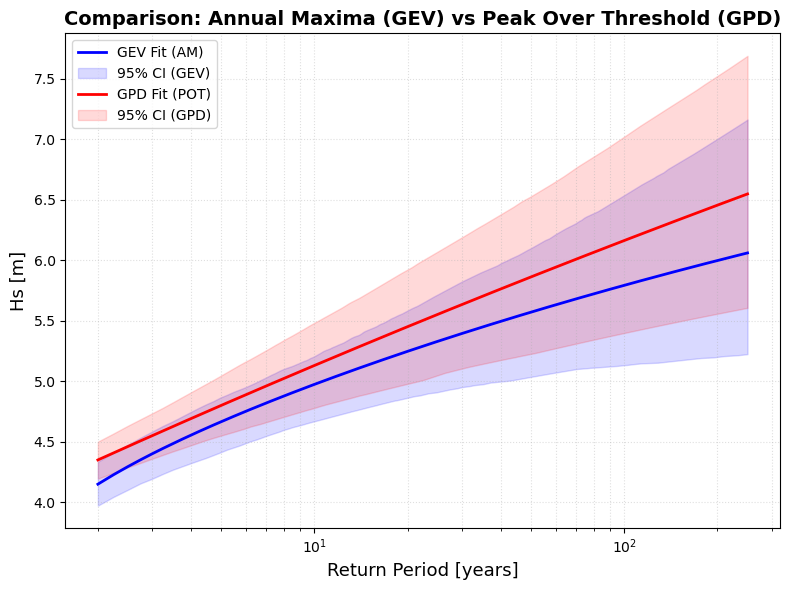

In [25]:
# Comparison plot of GEV (AM) and GPD (POT) confidence intervals
plt.figure(figsize=(8, 6))

# Plot GEV (Annual Maxima) results
#plt.scatter(T, dfs[var], color='dodgerblue', label='Empirical (AM)', s=25, alpha=0.7)
plt.plot(T_fit, rL, color='blue', linewidth=2, label='GEV Fit (AM)')
plt.fill_between(T_fit, ci_L_GEV, ci_U_GEV,
                 color='blue', alpha=0.15,
                 label='95% CI (GEV)')

# Plot GPD (POT) results
#plt.scatter(T_empirical, peaks_sorted, color='coral', label='Empirical (POT)', s=25, alpha=0.7, marker='s')
plt.plot(T_fit, rL_pot, color='red', linewidth=2, label='GPD Fit (POT)')
plt.fill_between(T_fit, ci_L_pot, ci_U_pot,
                 color='red', alpha=0.15,
                 label='95% CI (GPD)')

plt.xscale('log')
plt.xlabel('Return Period [years]', fontsize=13)
plt.ylabel(var + un_var[var], fontsize=13)
plt.title('Comparison: Annual Maxima (GEV) vs Peak Over Threshold (GPD)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.4, linestyle='dotted', which='both')
plt.tight_layout()
plt.show()

In [26]:
# Fit GPD with SciPy (MLE) in a separate cell
# This overwrites c_gp, loc_gp, scale_gp for downstream plots/calc.
var = 'Hs'
peaks_data = peaks_df[var].values

u = thrsld
exceedances = peaks_data - u
exceedances = exceedances[exceedances >= 0]

if len(exceedances) < 3:
    raise ValueError('Need at least 3 exceedances for GPD fitting.')

# Fit on exceedances with location fixed at 0
c_gp, loc_exc, scale_gp = stats.genpareto.fit(exceedances, floc=0)
loc_gp = u

print("=" * 60)
print("GENERALIZED PARETO DISTRIBUTION (POT METHOD)")
print("=" * 60)
print("Fit method: SciPy genpareto.fit (MLE, exceedances above threshold)")
print(f"Generalized Pareto parameters:")
print(f"  Shape (c): {c_gp:.4f}")
print(f"  Location: {loc_gp:.4f} - Thrsld {thrsld:.4f}")
print(f"  Scale: {scale_gp:.4f}")
print(f"  Fitted exceedance location (fixed): {loc_exc:.4f}")
print(f"  Number of peaks: {len(peaks_data)}")
print("=" * 60)

GENERALIZED PARETO DISTRIBUTION (POT METHOD)
Fit method: SciPy genpareto.fit (MLE, exceedances above threshold)
Generalized Pareto parameters:
  Shape (c): -0.0555
  Location: 2.7440 - Thrsld 2.7440
  Scale: 0.5702
  Fitted exceedance location (fixed): 0.0000
  Number of peaks: 473


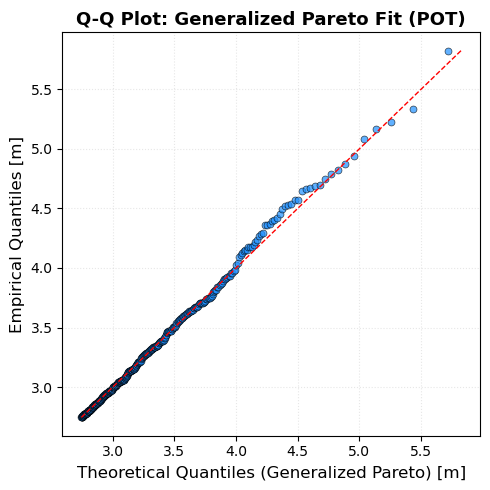

In [27]:
# Q-Q Plot: Theoretical vs Empirical Quantiles (Pareto)
# Sort observed peaks data
observed_sorted = np.sort(peaks_data)
n_peaks = len(observed_sorted)

# Calculate empirical probabilities using plotting positions
empirical_prob_peaks = np.arange(1, n_peaks + 1) / (n_peaks + 1)

# Calculate theoretical quantiles from fitted Generalized Pareto distribution
theoretical_quantiles_gp = stats.genpareto.ppf(empirical_prob_peaks, c_gp, loc=loc_gp, scale=scale_gp)

# Create Q-Q plot
plt.figure(figsize=(5, 5))
plt.scatter(theoretical_quantiles_gp, observed_sorted, color='dodgerblue', 
            s=25, alpha=0.7, edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
min_val = min(theoretical_quantiles_gp.min(), observed_sorted.min())
max_val = max(theoretical_quantiles_gp.max(), observed_sorted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)

plt.xlabel(f'Theoretical Quantiles (Generalized Pareto){un_var[var]}', fontsize=12)
plt.ylabel(f'Empirical Quantiles{un_var[var]}', fontsize=12)
plt.title('Q-Q Plot: Generalized Pareto Fit (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()


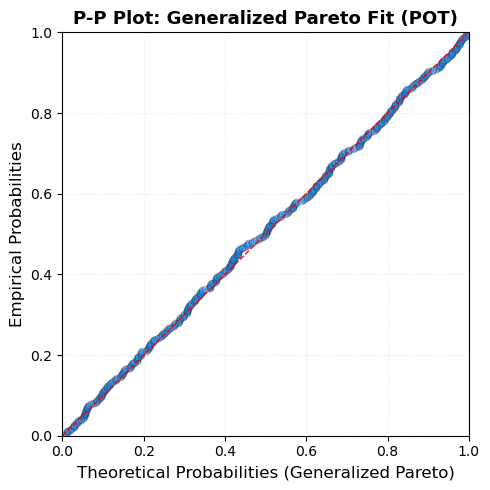

In [28]:
# P-P Plot: Theoretical vs Empirical Probabilities (Pareto)
# Calculate theoretical probabilities from fitted Generalized Pareto distribution
theoretical_prob_gp = stats.genpareto.cdf(observed_sorted, c_gp, loc=loc_gp, scale=scale_gp)

# Create P-P plot
plt.figure(figsize=(5, 5))
plt.scatter(theoretical_prob_gp, empirical_prob_peaks, color='dodgerblue', s=25, alpha=0.3, 
            edgecolors='black', linewidth=0.5)

# Add 1:1 reference line
plt.plot([0, 1], [0, 1], 'r--', linewidth=1)

plt.xlabel('Theoretical Probabilities (Generalized Pareto)', fontsize=12)
plt.ylabel('Empirical Probabilities', fontsize=12)
plt.title('P-P Plot: Generalized Pareto Fit (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()


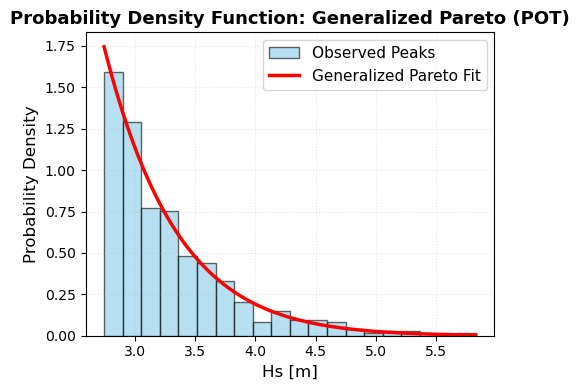

In [29]:
# PDF Plot: Histogram vs Fitted Generalized Pareto Distribution
# Create x-values for the fitted PDF curve
x_pdf_gp = np.linspace(peaks_data.min(), peaks_data.max(), 200)

# Calculate fitted PDF
pdf_fit_gp = stats.genpareto.pdf(x_pdf_gp, c_gp, loc=loc_gp, scale=scale_gp)

# Create plot
plt.figure(figsize=(5, 4))

# Plot histogram of observed data (normalized to represent density)
plt.hist(peaks_data, bins=20, density=True, alpha=0.6, color='skyblue', 
         edgecolor='black', label='Observed Peaks')

# Plot fitted Generalized Pareto PDF
plt.plot(x_pdf_gp, pdf_fit_gp, 'r-', linewidth=2.5, label='Generalized Pareto Fit')

plt.xlabel(var + un_var[var], fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title('Probability Density Function: Generalized Pareto (POT)', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, linestyle='dotted')
plt.tight_layout()
plt.show()


Data duration: 46.08 years
Total peaks: 473
Average peaks per year: 10.26


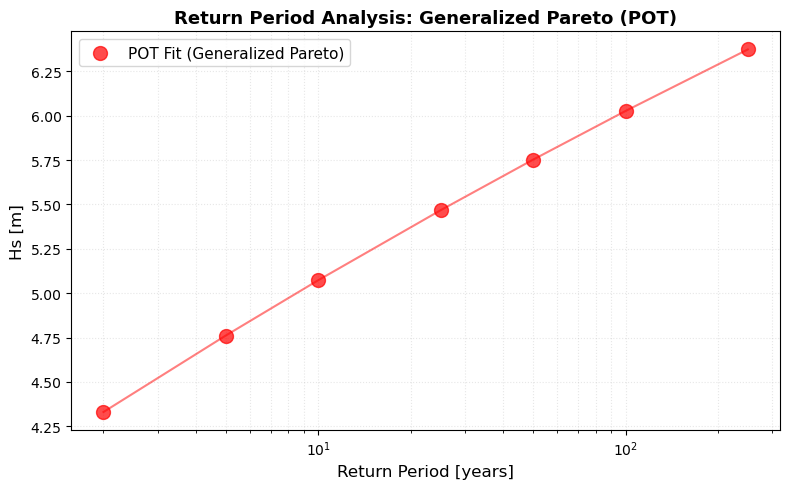


Return Period Quantiles (POT Method):
Return Period (years) | Quantile Value
----------------------------------------
                 2.0 |          4.330 m
                 5.0 |          4.761 m
                10.0 |          5.073 m
                25.0 |          5.467 m
                50.0 |          5.752 m
               100.0 |          6.026 m
               250.0 |          6.373 m


In [30]:
# Return Period Analysis for Generalized Pareto (POT method)
# Number of peaks per year
n_peaks_total = len(peaks_df)
# Assuming the data covers a certain time period, calculate peaks per year
data_duration_years = (pdW.index[-1] - pdW.index[0]).days / 365.25
peaks_per_year = n_peaks_total / data_duration_years

print(f"Data duration: {data_duration_years:.2f} years")
print(f"Total peaks: {n_peaks_total}")
print(f"Average peaks per year: {peaks_per_year:.2f}")

# Define return periods to calculate
return_periods = np.array([2, 5, 10, 25, 50, 100, 250])

# For POT method: P(X > x) = lambda * P_gp(X > x)
# where lambda is peaks per year
# Return period T = 1 / (lambda * (1 - P_gp(x)))

# Calculate quantiles for each return period
quantiles_pot = []
for T in return_periods:
    # Solve for x: T = 1 / (lambda * (1 - CDF(x)))
    # 1 - CDF(x) = 1 / (T * lambda)
    exceedance_prob = 1 / (T * peaks_per_year)
    # CDF(x) = 1 - exceedance_prob
    cdf_target = 1 - exceedance_prob
    x_quantile = stats.genpareto.ppf(cdf_target, c_gp, loc=loc_gp, scale=scale_gp)
    quantiles_pot.append(x_quantile)

quantiles_pot = np.array(quantiles_pot)

# Create return period plot
plt.figure(figsize=(8, 5))
plt.scatter(return_periods, quantiles_pot, color='red', s=100, zorder=5, label='POT Fit (Generalized Pareto)', alpha=0.7)
plt.plot(return_periods, quantiles_pot, 'r-', linewidth=1.5, alpha=0.5)
plt.xscale('log')
plt.xlabel('Return Period [years]', fontsize=12)
plt.ylabel(var + un_var[var], fontsize=12)
plt.title('Return Period Analysis: Generalized Pareto (POT)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='dotted', which='both')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print return period values
print("\nReturn Period Quantiles (POT Method):")
print("Return Period (years) | Quantile Value")
print("-" * 40)
for T, q in zip(return_periods, quantiles_pot):
    print(f"{T:20.1f} | {q:14.3f} m")
